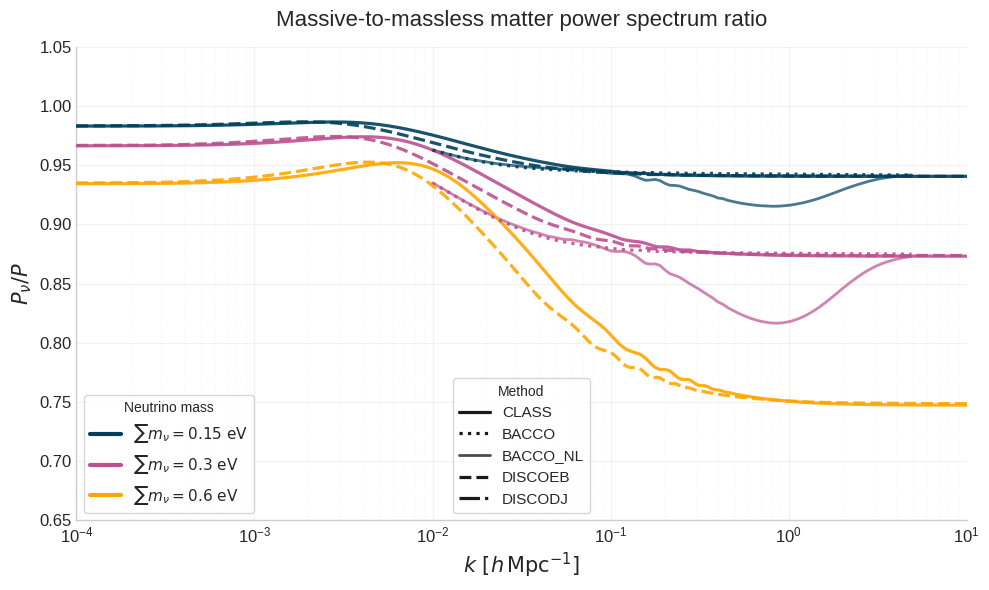

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl


#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})


class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)
discodj_data = np.load("discodj_results.npy", allow_pickle=True)

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
   + list(discoeb_data)
   # + list(discodj_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))


masses = sorted(set(d["mass"] for d in all_data))

# Much cleaner palette
mass_colors = {
    0.15: "#003f5c",  # dark blue
    0.3: "#bc5090", # magenta
    0.6: "#ffa600",  # yellow-orange
}

method_styles = {
    "CLASS": dict(
        ls="-",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    # BACCO linear
    "BACCO": dict(
        ls=":",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    # BACCO nonlinear
    "BACCO_NL": dict(
        ls="-",
        lw=2.0,
        alpha=0.7,
        zorder=2,
    ),

    "DISCOEB": dict(
        ls="--",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    "DISCODJ": dict(
        ls="-.",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),
}

for d in all_data:

    k       = d["k"]
    ratio   = d["ratio"]
    mass    = d["mass"]
    method  = d["method"]

    color = mass_colors[mass]

    # Important: BACCO_NL avant BACCO
    if "BACCO_NL" in method:
        style = method_styles["BACCO_NL"]

    elif "BACCO" in method:
        style = method_styles["BACCO"]

    elif "CLASS" in method:
        style = method_styles["CLASS"]

    elif "DISCOEB" in method:
        style = method_styles["DISCOEB"]

    elif "DISCODJ" in method:
        style = method_styles["DISCODJ"]

    ax.semilogx(
        k,
        ratio,
        color=color,
        **style
    )

ax.set_xlabel(
    r"$k\ [h\,\mathrm{Mpc}^{-1}]$",
    fontsize=15
)

ax.set_ylabel(
    r"$P_\nu/P$",
    fontsize=15
)

ax.set_xlim(1e-4, 10)
ax.set_ylim(0.65, 1.05)

# Cleaner grid
ax.grid(True, which="major", linestyle="-", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=12)

# ----- Mass legend (colors)
mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu = {m}\ \mathrm{{eV}}$"
    )
    for m in masses
]

# ----- Method legend (linestyles)
method_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=method_styles[m]["lw"],
        ls=method_styles[m]["ls"],
        alpha=method_styles[m]["alpha"],
        label=m.replace("_", r"_")
        
    )
    for m in method_styles
]

legend1 = ax.legend(
    handles=mass_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
    title="Neutrino mass"
)

legend2 = ax.legend(
    handles=method_handles,
    loc="lower center",
    fontsize=11,
    frameon=True,
    title="Method"
)

ax.add_artist(legend1)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    r"Massive-to-massless matter power spectrum ratio",
    fontsize=16,
    pad=15
)

plt.tight_layout()

#plt.savefig("comp.pgf", bbox_inches="tight")
plt.show()